# Null test

No Niche at all

In [3]:
import os
os.environ["R_HOME"] = "/work/nagar_F2657_csv/miniconda3/envs/venv_quiche_3D_simple/lib/R"

import sim_unstructured as sim
from collections import Counter

import os
import pandas as pd
import numpy as np
import quiche as qu
import scanpy as sc
import anndata as ad
import squidpy as sq
import matplotlib.pyplot as plt

%reload_ext autoreload
%load_ext autoreload
%autoreload 2
%matplotlib inline

#sc.set_figure_params(dpi = 400, dpi_save = 400, fontsize = 14)
#sc.set_figure_params(dpi = 120, dpi_save = 300, fontsize = 14) # smaller plots for now

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Helper functions:

In [4]:
def cells_to_adata(cells):
    cells = cells.copy()

    cells["condition"] = cells["condition"].astype(str)
    cells["fov"] = cells["patient_id"]
    cells["cell_cluster"] = pd.Categorical(cells["cell_type"])
    cells["label"] = cells["cell_id"].astype(str)

    X_df = pd.get_dummies(cells["cell_cluster"], dtype=float)
    X = X_df.to_numpy()

    adata = ad.AnnData(X=X)
    adata.obs_names = cells["cell_id"].astype(str).values

    obs_cols = [
        "patient_id",
        "condition",
        "fov",
        "label",
        "cell_cluster",
        "cell_type",
        "gt_region_label",
        "in_niche_voxel",
    ]

    adata.obs = cells[obs_cols].copy()
    adata.obs.index = adata.obs_names
    adata.obs = adata.obs.rename(columns={"patient_id": "Patient_ID"})

    adata.obs["Patient_ID"] = adata.obs["Patient_ID"].astype("category")
    adata.obs["fov"] = adata.obs["fov"].astype("category")
    adata.obs["condition"] = adata.obs["condition"].astype("category")
    adata.obs["cell_cluster"] = pd.Categorical(adata.obs["cell_cluster"])

    adata.obsm["spatial3d"] = cells[["x", "y", "z"]].to_numpy().astype(float)
    adata.var_names = X_df.columns.astype(str)

    return adata

In [5]:
def run_quiche_once(
    adata,
    condition_key="condition",
    radius=25,
    n_neighbors=30,
    k_sim=50,
    sketch_size=None,
):
    adata = adata.copy()

    q = qu.tl.QUICHE(
        adata=adata,
        labels_key="cell_cluster",
        spatial_key="spatial3d",
        fov_key="fov",
        patient_key="Patient_ID",
        segmentation_label_key="label",
    )

    q.compute_spatial_niches(
        radius=radius,
        n_neighbors=n_neighbors,
        khop=None,
        min_cell_threshold=3,
        coord_type="generic",
        delaunay=False,
    )

    q.subsample(sketch_size=sketch_size)

    q.differential_enrichment(
        k_sim=k_sim,
        design=f"~{condition_key}",
        model_contrasts=f"{condition_key}1-{condition_key}0",
    )

    q.annotate_niches(
        annotation_scheme="neighborhood",
        annotation_key="quiche_niche",
        nlargest=3,
        min_perc=0.1,
    )

    return q

In [6]:
def summarize_quiche_null(q, label="null"):
    quiche_var = q.mdata["quiche"].var.copy()

    sig_frac = (quiche_var["SpatialFDR"] < 0.05).mean()
    n_sig = (quiche_var["SpatialFDR"] < 0.05).sum()

    summary = {
        "test": label,
        "n_niches": quiche_var.shape[0],
        "n_significant": int(n_sig),
        "frac_significant": float(sig_frac),
        "mean_logFC": float(quiche_var["logFC"].mean()),
        "median_logFC": float(quiche_var["logFC"].median()),
        "min_logFC": float(quiche_var["logFC"].min()),
        "max_logFC": float(quiche_var["logFC"].max()),
        "mean_SpatialFDR": float(quiche_var["SpatialFDR"].mean()),
        "min_SpatialFDR": float(quiche_var["SpatialFDR"].min()),
    }

    return pd.DataFrame([summary]), quiche_var

# Null test 1: Pure 0

In [7]:
cfg_null = sim.SimConfig(
    n_patients=20,
    n_conditions=2,
    cells_per_patient=5000,
    domain_size=300.0,
    grid_size=3,
    prevalence=0.0,   # no planted niche
    random_state=42,
    preserve_global_counts=True,
)

cells_null, meta_null = sim.simulate_cohort(cfg_null)
adata_null = cells_to_adata(cells_null)

print(meta_null["has_niche"].value_counts())
adata_null

has_niche
False    20
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 100000 × 5
    obs: 'Patient_ID', 'condition', 'fov', 'label', 'cell_cluster', 'cell_type', 'gt_region_label', 'in_niche_voxel'
    obsm: 'spatial3d'

In [8]:
q_null = run_quiche_once(
    adata_null,
    condition_key="condition",
    radius=25,
    n_neighbors=30,
    k_sim=50,
    sketch_size=None,
)

INFO:quiche.tools.quiche:Converted 'fov' to categorical.
INFO:quiche.tools.quiche:Computing spatial niches...
INFO:quiche.tools.quiche:Skipping distribution-focused downsampling.
INFO:quiche.tools.quiche:Testing for differential spatial enrichment across conditions...
INFO:quiche.tools.quiche:Annotating niches using scheme: neighborhood...
Labeling Niches: 100%|██████████| 99966/99966 [00:03<00:00, 32286.88it/s]


### Summarize results

In [9]:
summary_null, quiche_var_null = summarize_quiche_null(q_null, label="pure_null")
display(summary_null)

display(
    quiche_var_null.sort_values("SpatialFDR")[
        ["quiche_niche", "logFC", "PValue", "SpatialFDR", "gt_region_label"]
    ].head(20)
)

,test,n_niches,n_significant,frac_significant,mean_logFC,median_logFC,min_logFC,max_logFC,mean_SpatialFDR,min_SpatialFDR
0,pure_null,99966,0,0.0,-0.010755,-0.007917,-5.444936,2.884252,0.990656,0.450513


,quiche_niche,logFC,PValue,SpatialFDR,gt_region_label
22760,A__C__D,-5.361281,2.147939e-14,0.450513,background
26225,C__D__E,-4.486742,1.538365e-12,0.450513,background
21473,B__D__E,-2.302277,3.228979e-07,0.450513,background
13574,C__D__E,-3.409136,4.640161e-05,0.450513,background
9647,B__C__E,-5.361091,2.154864e-14,0.450513,background
16451,A__D__E,-5.361814,2.128649e-14,0.450513,background
11067,B__D__E,-5.388856,1.086802e-14,0.450513,background
9513,B__C__D,-2.180772,2.486435e-06,0.450513,background
19500,C__D__E,-2.031322,1.944805e-09,0.450513,background
5137,C__D__E,-1.754423,1.519373e-06,0.450513,background


### Plot LogFC distribution

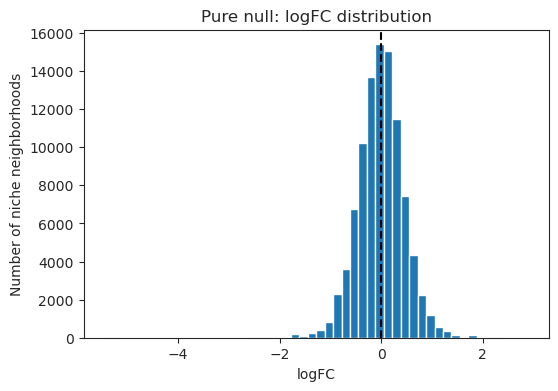

In [10]:
plt.figure(figsize=(6, 4))
plt.hist(quiche_var_null["logFC"], bins=50)
plt.axvline(0, linestyle="--", color="black")
plt.title("Pure null: logFC distribution")
plt.xlabel("logFC")
plt.ylabel("Number of niche neighborhoods")
plt.show()

# Null test 2: Shuffle condition labels

In [27]:
cfg_signal = sim.SimConfig(
    n_patients=20,
    n_conditions=2,
    cells_per_patient=5000,
    domain_size=300.0,
    grid_size=3,
    prevalence=1.0,
    random_state=42,
    preserve_global_counts=True,
)

cells_signal, meta_signal = sim.simulate_cohort(cfg_signal)
adata_shuffle = cells_to_adata(cells_signal)

In [28]:
# Start from the true signal simulation
cells_shuffle = cells_signal.copy()

# Build patient-level truth table
def get_patient_region_type(x):
    vals = sorted([v for v in x.unique() if v != "background"])
    return vals[0] if len(vals) > 0 else "none"

patient_truth = (
    cells_shuffle
    .groupby("patient_id")
    .agg(
        original_condition=("condition", "first"),
        gt_region_type=("gt_region_label", get_patient_region_type),
    )
)

display(patient_truth)

,original_condition,gt_region_type
patient_id,,
P00,0,ACE_region
P01,0,ACE_region
P02,0,ACE_region
P03,0,ACE_region
P04,0,ACE_region
P05,0,ACE_region
P06,0,ACE_region
P07,0,ACE_region
P08,0,ACE_region


In [29]:
rng = np.random.default_rng(123)

new_conditions = {}

# Force each true region type to be split across condition 0 and 1
for region_type, df_region in patient_truth.groupby("gt_region_type"):
    patient_ids = df_region.index.to_numpy().copy()
    rng.shuffle(patient_ids)

    n = len(patient_ids)
    labels = np.array(["0", "1"] * ((n // 2) + 1))[:n]
    rng.shuffle(labels)

    for pid, new_cond in zip(patient_ids, labels):
        new_conditions[pid] = new_cond

patient_truth["shuffled_condition"] = patient_truth.index.map(new_conditions)

display(patient_truth)

,original_condition,gt_region_type,shuffled_condition
patient_id,,,
P00,0,ACE_region,1
P01,0,ACE_region,0
P02,0,ACE_region,0
P03,0,ACE_region,0
P04,0,ACE_region,1
P05,0,ACE_region,0
P06,0,ACE_region,1
P07,0,ACE_region,0
P08,0,ACE_region,1


In [30]:
print("Original condition vs shuffled condition:")
display(pd.crosstab(
    patient_truth["original_condition"].astype(str),
    patient_truth["shuffled_condition"]
))

print("GT region type vs shuffled condition:")
display(pd.crosstab(
    patient_truth["gt_region_type"],
    patient_truth["shuffled_condition"]
))

Original condition vs shuffled condition:


shuffled_condition,0,1
original_condition,,
0,5,5
1,5,5


GT region type vs shuffled condition:


shuffled_condition,0,1
gt_region_type,,
ACE_region,5,5
BD_region,5,5


In [31]:
cells_shuffle["condition"] = (
    cells_shuffle["patient_id"]
    .map(new_conditions)
    .astype(str)
)

adata_shuffle = cells_to_adata(cells_shuffle)

In [32]:
q_shuffle = run_quiche_once(
    adata_shuffle,
    condition_key="condition",
    radius=25,
    n_neighbors=30,
    k_sim=50,
    sketch_size=None,
)

summary_shuffle, quiche_var_shuffle = summarize_quiche_null(
    q_shuffle,
    label="condition_shuffle_balanced"
)

display(summary_shuffle)

INFO:quiche.tools.quiche:Converted 'fov' to categorical.
INFO:quiche.tools.quiche:Computing spatial niches...
INFO:quiche.tools.quiche:Skipping distribution-focused downsampling.
INFO:quiche.tools.quiche:Testing for differential spatial enrichment across conditions...
INFO:quiche.tools.quiche:Annotating niches using scheme: neighborhood...
Labeling Niches: 100%|██████████| 99971/99971 [00:02<00:00, 33502.87it/s]


,test,n_niches,n_significant,frac_significant,mean_logFC,median_logFC,min_logFC,max_logFC,mean_SpatialFDR,min_SpatialFDR
0,condition_shuffle_balanced,99971,0,0.0,-0.040874,-0.039962,-2.906492,2.414971,0.985396,0.984296


### Plot

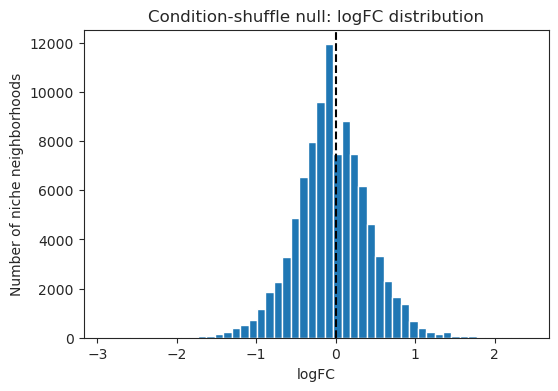

In [33]:
plt.figure(figsize=(6, 4))
plt.hist(quiche_var_shuffle["logFC"], bins=50)
plt.axvline(0, linestyle="--", color="black")
plt.title("Condition-shuffle null: logFC distribution")
plt.xlabel("logFC")
plt.ylabel("Number of niche neighborhoods")
plt.show()

# Null test 3: Same niche in both conditions

In [16]:
cfg_same = sim.SimConfig(
    n_patients=20,
    n_conditions=2,
    cells_per_patient=5000,
    domain_size=300.0,
    grid_size=3,
    prevalence=1.0,
    random_state=42,
    preserve_global_counts=True,
)

cells_same, meta_same = sim.simulate_cohort(cfg_same)
cells_same = cells_same.copy()

rng = np.random.default_rng(456)

# Force all planted regions, including condition 1, to be ACE-like
mask_planted = cells_same["in_niche_voxel"].to_numpy()
cells_same.loc[mask_planted, "cell_type"] = rng.choice(
    ["A", "C", "E"],
    size=mask_planted.sum(),
    replace=True,
)

# Rename all GT planted regions as same-region
cells_same.loc[cells_same["in_niche_voxel"], "gt_region_label"] = "ACE_region"
cells_same.loc[~cells_same["in_niche_voxel"], "gt_region_label"] = "background"

adata_same = cells_to_adata(cells_same)

print(cells_same.groupby(["condition", "gt_region_label"]).size())

condition  gt_region_label
0          ACE_region          1824
           background         48176
1          ACE_region          1898
           background         48102
dtype: int64


In [17]:
q_same = run_quiche_once(
    adata_same,
    condition_key="condition",
    radius=25,
    n_neighbors=30,
    k_sim=50,
    sketch_size=None,
)

INFO:quiche.tools.quiche:Converted 'fov' to categorical.
INFO:quiche.tools.quiche:Computing spatial niches...
INFO:quiche.tools.quiche:Skipping distribution-focused downsampling.
INFO:quiche.tools.quiche:Testing for differential spatial enrichment across conditions...
INFO:quiche.tools.quiche:Annotating niches using scheme: neighborhood...
Labeling Niches: 100%|██████████| 99971/99971 [00:02<00:00, 38966.25it/s]


### Summary

In [18]:
summary_same, quiche_var_same = summarize_quiche_null(q_same, label="same_niche_both_conditions")
display(summary_same)

display(
    quiche_var_same.sort_values("SpatialFDR")[
        ["quiche_niche", "logFC", "PValue", "SpatialFDR", "gt_region_label"]
    ].head(20)
)

,test,n_niches,n_significant,frac_significant,mean_logFC,median_logFC,min_logFC,max_logFC,mean_SpatialFDR,min_SpatialFDR
0,same_niche_both_conditions,99971,82,0.00082,-0.018193,-0.00813,-5.420942,3.604385,0.746906,0.036044


,quiche_niche,logFC,PValue,SpatialFDR,gt_region_label
37601,A__E,-2.924740,1.764381e-08,0.036044,background
28770,B__C__E,-5.365294,2.124301e-14,0.036044,background
8527,B__D__E,-2.299100,1.619191e-06,0.036044,background
21693,B__D__E,-5.362962,2.211580e-14,0.036044,background
9305,A__C,-2.168915,9.689264e-07,0.036044,ACE_region
25635,C__D__E,-5.389607,1.147241e-14,0.036044,background
10937,C__D__E,-5.420942,5.469889e-15,0.036044,background
79140,A__C__E,1.610840,4.131924e-06,0.036044,background
22572,B__C__D,-2.274880,5.988282e-07,0.036044,background
3327,B__C__D,-2.712382,6.318750e-08,0.036044,background


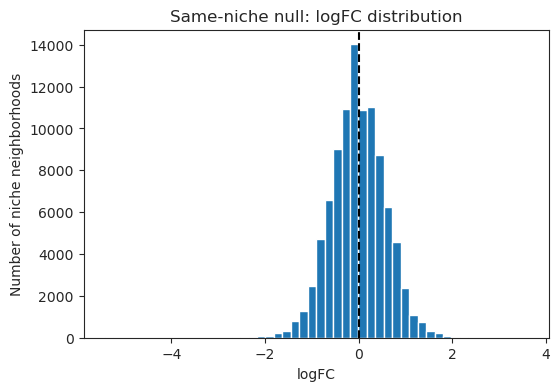

In [19]:
plt.figure(figsize=(6, 4))
plt.hist(quiche_var_same["logFC"], bins=50)
plt.axvline(0, linestyle="--", color="black")
plt.title("Same-niche null: logFC distribution")
plt.xlabel("logFC")
plt.ylabel("Number of niche neighborhoods")
plt.show()

# Compare

In [20]:
phase4_summary = pd.concat(
    [summary_null, summary_shuffle, summary_same],
    ignore_index=True
)

display(phase4_summary)

,test,n_niches,n_significant,frac_significant,mean_logFC,median_logFC,min_logFC,max_logFC,mean_SpatialFDR,min_SpatialFDR
0,pure_null,99966,0,0.000000,-0.010755,-0.007917,-5.444936,2.884252,0.990656,4.505128e-01
1,condition_shuffle,99971,2305,0.023057,0.005086,0.000844,-5.414662,6.160032,0.790822,4.143447e-22
2,same_niche_both_conditions,99971,82,0.000820,-0.018193,-0.008130,-5.420942,3.604385,0.746906,3.604444e-02


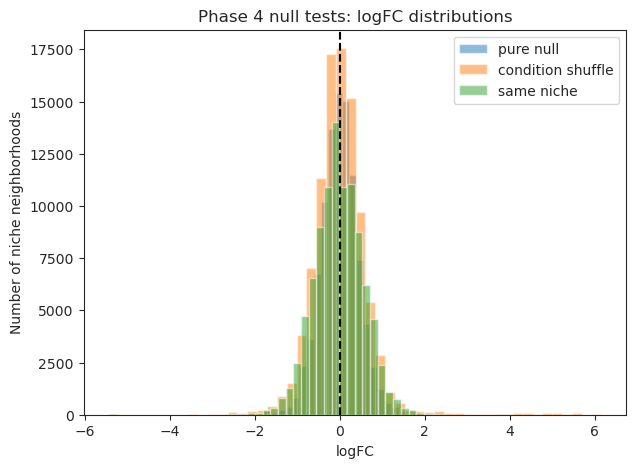

In [21]:
plt.figure(figsize=(7, 5))

plt.hist(
    quiche_var_null["logFC"],
    bins=50,
    alpha=0.5,
    label="pure null",
)

plt.hist(
    quiche_var_shuffle["logFC"],
    bins=50,
    alpha=0.5,
    label="condition shuffle",
)

plt.hist(
    quiche_var_same["logFC"],
    bins=50,
    alpha=0.5,
    label="same niche",
)

plt.axvline(0, linestyle="--", color="black")
plt.xlabel("logFC")
plt.ylabel("Number of niche neighborhoods")
plt.title("Phase 4 null tests: logFC distributions")
plt.legend()
plt.show()

## Compare to positive phase 3

In [24]:
cfg_signal = sim.SimConfig(
    n_patients=20,
    n_conditions=2,
    cells_per_patient=5000,
    domain_size=300.0,
    grid_size=3,
    prevalence=1.0,
    random_state=42,
    preserve_global_counts=True,
)

cells_signal, meta_signal = sim.simulate_cohort(cfg_signal)
adata_shuffle = cells_to_adata(cells_signal)

In [25]:
q_signal = run_quiche_once(
    cells_to_adata(cells_signal),
    condition_key="condition",
    radius=25,
    n_neighbors=30,
    k_sim=50,
    sketch_size=None,
)

summary_signal, quiche_var_signal = summarize_quiche_null(q_signal, label="true_signal")
display(summary_signal)

INFO:quiche.tools.quiche:Converted 'fov' to categorical.
INFO:quiche.tools.quiche:Computing spatial niches...
INFO:quiche.tools.quiche:Skipping distribution-focused downsampling.
INFO:quiche.tools.quiche:Testing for differential spatial enrichment across conditions...
INFO:quiche.tools.quiche:Annotating niches using scheme: neighborhood...
Labeling Niches: 100%|██████████| 99971/99971 [00:06<00:00, 16591.03it/s]


,test,n_niches,n_significant,frac_significant,mean_logFC,median_logFC,min_logFC,max_logFC,mean_SpatialFDR,min_SpatialFDR
0,true_signal,99971,2305,0.023057,0.005086,0.000844,-5.414662,6.160032,0.790822,4.143447e-22


In [34]:
phase4_plus_signal = pd.concat(
    [summary_signal, summary_null, summary_shuffle, summary_same],
    ignore_index=True
)

display(phase4_plus_signal)

,test,n_niches,n_significant,frac_significant,mean_logFC,median_logFC,min_logFC,max_logFC,mean_SpatialFDR,min_SpatialFDR
0,true_signal,99971,2305,0.023057,0.005086,0.000844,-5.414662,6.160032,0.790822,4.143447e-22
1,pure_null,99966,0,0.000000,-0.010755,-0.007917,-5.444936,2.884252,0.990656,4.505128e-01
2,condition_shuffle_balanced,99971,0,0.000000,-0.040874,-0.039962,-2.906492,2.414971,0.985396,9.842962e-01
3,same_niche_both_conditions,99971,82,0.000820,-0.018193,-0.008130,-5.420942,3.604385,0.746906,3.604444e-02


true_signal       → clear significant fraction + directional logFC

pure_null         → very low significant fraction, logFC near 0

condition_shuffle → very low significant fraction, logFC near 0

same_niche        → very low significant fraction, logFC near 0